# Last-frame model dRSA after removing the 2250-ms model RDM

This notebook tests whether the model-depth temporal score survives after removing the representational geometry already present 250 ms before the movie's final frame. For each model layer, it computes the 2250-ms and 2500-ms model RDMs across the same stimuli and fits

$$d_{2500} = \alpha + \beta d_{2250} + \varepsilon.$$

The residual RDM vector $\varepsilon$ is then compared with every dynamic-neural RDM time point. The neural data are never residualized. Raw and residualized final-frame timecourses are summarized with the same peak and positive-mass centroid latencies used by the existing presentation analysis, and the **temporal score** is Spearman $\rho$ between normalized layer depth and latency.

Regression is performed across the unique off-diagonal stimulus pairs. With an intercept, the residual is exactly orthogonal to the 2250-ms predictor in Pearson space. Because the configured RSA can be Spearman, the notebook also reports the remaining rank correlation as a diagnostic.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path("../..").resolve()

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
    match_feature_stimulus_names,
)
from project_specific_utils import (
    compute_rdm_timeseries, cross_temporal_similarity,
    last_frame_residual_similarity, load_natraster,
    match_timed_static_movie_rasters, prepare_static_neural_rdms,
)
from useful_stuff.general_utils import TimeSeries, create_RDM
from useful_stuff.general_utils.RSA import dRSA

In [2]:
@dataclass
class Cfg:
    dynamic_exp_name: str = "red_20260720to0927"
    static_exp_name: str = "red_20260726to0925"

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (1, 64)
    top_k: int | None = None
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = "red_20260726to0923"

    source_neural_fs: float = 1000
    analysis_fs: float = 100
    neural_rdm_metric: str = "cosine_cnt"
    model_rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "spearman"

    model_name: str = "ijepa_vith14_1k" #"dino_v3_h" #"alexnet" #"alexnet" # 
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "PC1000"
    model_features_dir: Path | None = None

    previous_frame_ms: float = 2250
    last_frame_ms: float = 2500
    regression_fit_intercept: bool = True

    # End-exclusive neural-time windows for the two latency measures.
    centroid_window_ms: tuple[float, float] = (2300, 2700)
    peak_window_ms: tuple[float, float] = (2300, 2700)
    smoothing_sigma_samples: float = 3
    centroid_similarity_cutoff: float = 0.01
    peak_similarity_cutoff: float = 0.01

    # Sample the same movie-time grid as the presentation figure.
    frame_residual_delay_ms: float = 250
    frame_latency_n_scatterplots: int = 20
    frame_latency_grid_shape: tuple[int, int] = (4, 5)
    frame_latency_window_ms: tuple[float, float] = (-500, 500)
    frame_latency_measure: str = "centroid"
    frame_latency_grid_figsize: tuple[float, float] = (20, 16)
    frame_latency_scatter_size: float = 55
    frame_latency_edge_color: str = "black"
    frame_latency_edge_width: float = 0.8

    # Image session: crop from image onset and end-exclusive peak-fit window.
    image_crop_ms: float = 1000
    image_peak_window_ms: tuple[float, float] = (0, 400)
    linewidth: float = 2
    figure_dpi: int = 120


cfg = Cfg()
if cfg.previous_frame_ms >= cfg.last_frame_ms:
    raise ValueError("previous_frame_ms must precede last_frame_ms.")
# end if frame order is invalid
for timing_name, timing_window_ms in (
        ("centroid", cfg.centroid_window_ms),
        ("peak", cfg.peak_window_ms),
        ):
    window_start_ms, window_end_ms = timing_window_ms
    if (
            not np.isfinite(window_start_ms)
            or not np.isfinite(window_end_ms)
            or window_start_ms >= window_end_ms
            ):
        raise ValueError(
            f"{timing_name}_window_ms must be finite and increasing."
        )
    # end if timing window is invalid
    if not window_start_ms <= cfg.last_frame_ms < window_end_ms:
        raise ValueError(
            f"{timing_name}_window_ms must contain last_frame_ms."
        )
    # end if timing window excludes the last frame
# end for timing_name, timing_window_ms
if cfg.rsa_metric not in {"correlation", "spearman"}:
    raise ValueError("rsa_metric must be 'correlation' or 'spearman'.")
# end if unsupported RSA metric
if cfg.frame_residual_delay_ms <= 0:
    raise ValueError("frame_residual_delay_ms must be positive.")
# end if frame residual delay is invalid
if cfg.frame_latency_n_scatterplots < 1:
    raise ValueError("frame_latency_n_scatterplots must be positive.")
# end if frame plot count is invalid
if np.prod(cfg.frame_latency_grid_shape) != cfg.frame_latency_n_scatterplots:
    raise ValueError(
        "frame_latency_grid_shape must contain the requested panels."
    )
# end if frame grid shape is inconsistent
if cfg.frame_latency_window_ms[0] >= cfg.frame_latency_window_ms[1]:
    raise ValueError("frame_latency_window_ms must be increasing.")
# end if frame latency window is invalid
if cfg.frame_latency_measure not in {"centroid", "peak"}:
    raise ValueError(
        "frame_latency_measure must be 'centroid' or 'peak'."
    )
# end if frame latency measure is invalid

model_features_dir = (
    cfg.model_features_dir or Path(paths["data_path"]) / "models"
)
dynamic_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
)
static_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.static_exp_name}_natraster_img.mat"
)
cfg

Cfg(dynamic_exp_name='baby1_260716to24', static_exp_name='baby1_260718to27', good_channels=(84, 186), top_k=None, use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_neural_fs=1000, analysis_fs=100, neural_rdm_metric='cosine_cnt', model_rdm_metric='cosine_cnt', rsa_metric='spearman', model_name='ijepa_vith14_1k', model_dataset_name='static_dynamic', model_pooling='PC1000', model_features_dir=None, previous_frame_ms=2250, last_frame_ms=2500, regression_fit_intercept=True, centroid_window_ms=(2300, 2700), peak_window_ms=(2300, 2700), smoothing_sigma_samples=3, centroid_similarity_cutoff=0.01, peak_similarity_cutoff=0.01, frame_residual_delay_ms=250, frame_latency_n_scatterplots=20, frame_latency_grid_shape=(4, 5), frame_latency_window_ms=(-500, 500), frame_latency_measure='centroid', frame_latency_grid_figsize=(20, 16), frame_latency_scatter_size=55, frame_latency_edge_color='black', frame_latency_edge_width=0.8, image_crop_ms=1000, image_peak_wi

## Load and align the dynamic neural responses

The static session is used only to recover the established 100-stimulus matched order. Channel selection is applied identically to the static and movie sessions, while only the movie response enters the analysis.

In [3]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

dynamic_loaded, dynamic_names, dynamic_channel_numbers = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
static_loaded, static_names, static_channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, dynamic_channel_numbers):
    raise ValueError("Static and dynamic sessions retained different channels.")
# end if retained channels differ

(
    _, dynamic_rasters, _, _, shared_stimuli, aligned_names,
) = match_timed_static_movie_rasters(
    static_loaded, static_names, dynamic_loaded, dynamic_names,
)

if cfg.top_k is not None:
    if cfg.top_k < 1 or cfg.top_k > dynamic_rasters.shape[0]:
        raise ValueError("top_k must fit inside the retained channel pool.")
    # end if invalid cfg.top_k
    channel_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = slice(None)
# end if cfg.top_k is not None

selected_channel_numbers = dynamic_channel_numbers[channel_indices]
dynamic_rasters = dynamic_rasters[channel_indices]
dynamic_ts = TimeSeries(dynamic_rasters, fs=cfg.source_neural_fs)
dynamic_ts.resample(cfg.analysis_fs)
dynamic_feature_names = [Path(name).name for name in aligned_names["movie"]]

print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected channels: {len(selected_channel_numbers)}")
print(
    f"Dynamic neural response: {dynamic_ts.shape()} "
    "(channels, time, stimuli)"
)

Matched stimuli: 100
Selected channels: 30
Dynamic neural response: (30, 350, 100) (channels, time, stimuli)


In [4]:
# Compute the dynamic-neural geometry once; every model layer reuses it.
dynamic_neural_rdms = compute_rdm_timeseries(
    dynamic_ts.get_array(), cfg.neural_rdm_metric,
)
dynamic_time_ms = (
    np.arange(dynamic_neural_rdms.shape[0]) * 1000 / dynamic_ts.get_fs()
)
print(
    f"Dynamic neural RDMs: {dynamic_neural_rdms.shape} "
    "(time, stimulus pairs)"
)

Dynamic neural RDMs: (350, 4950) (time, stimulus pairs)


## Residualize the final-frame model geometry

The regression has one observation per unique stimulus pair and is fit independently in every layer. This directly removes the component of the 2500-ms model RDM that is linearly predictable from its own 2250-ms RDM.

In [5]:
"""
regress_out_rdm
Remove one predictor RDM from a target RDM across matched stimulus pairs.

INPUT:
    - target_rdm: np.ndarray -> final-frame vectorized RDM.
    - predictor_rdm: np.ndarray -> earlier-frame vectorized RDM.
    - fit_intercept: bool -> whether to include a constant regression term.

OUTPUT:
    - residual_rdm: np.ndarray -> target variance unexplained by the predictor.
    - regression_summary: dict -> coefficients and variance diagnostics.
"""
def regress_out_rdm(target_rdm, predictor_rdm, fit_intercept=True):
    target_rdm = np.asarray(target_rdm, dtype=float)
    predictor_rdm = np.asarray(predictor_rdm, dtype=float)
    if target_rdm.ndim != 1 or target_rdm.shape != predictor_rdm.shape:
        raise ValueError(
            "target_rdm and predictor_rdm must be matching vectors."
        )
    # end if RDM shapes do not match
    if not np.all(np.isfinite(target_rdm)) or not np.all(
            np.isfinite(predictor_rdm)):
        raise ValueError("RDM regression requires finite distances.")
    # end if an RDM contains non-finite values

    design_columns = [predictor_rdm]
    if fit_intercept:
        design_columns.append(np.ones_like(predictor_rdm))
    # end if fit_intercept
    design_matrix = np.column_stack(design_columns)
    coefficients = np.linalg.lstsq(
        design_matrix, target_rdm, rcond=None,
    )[0]
    predicted_rdm = design_matrix @ coefficients
    residual_rdm = target_rdm - predicted_rdm

    target_variance = np.var(target_rdm)
    residual_variance = np.var(residual_rdm)
    variance_removed = (
        1 - residual_variance / target_variance
        if target_variance > 0 else np.nan
    )
    regression_summary = {
        "beta": coefficients[0],
        "intercept": coefficients[1] if fit_intercept else 0.0,
        "variance_removed": variance_removed,
        "predictor_target_pearson": np.corrcoef(
            predictor_rdm, target_rdm,
        )[0, 1],
        "predictor_residual_pearson": np.corrcoef(
            predictor_rdm, residual_rdm,
        )[0, 1],
        "predictor_target_spearman": spearmanr(
            predictor_rdm, target_rdm,
        ).statistic,
        "predictor_residual_spearman": spearmanr(
            predictor_rdm, residual_rdm,
        ).statistic,
    }
    return residual_rdm, regression_summary
# EOF

In [6]:
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name,
    cfg.model_pooling,
)
# Resolve exact HDF5 dataset names once and reuse their matched order.
model_stimulus_names = match_feature_stimulus_names(
    feature_paths[0], dynamic_feature_names,
)

layer_names = []
raw_similarity = []
residual_similarity = []
regression_summaries = []
source_model_fs = None
model_time_ms = None

for feature_path in feature_paths:
    model_features, layer_name, layer_source_fs = (
        load_aligned_video_features(
            feature_path, model_stimulus_names, frame_index=None,
        )
    )
    model_ts = TimeSeries(model_features, fs=layer_source_fs)
    model_ts.resample(cfg.analysis_fs)
    current_model_time_ms = (
        np.arange(len(model_ts)) * 1000 / model_ts.get_fs()
    )
    previous_frame_index = int(np.argmin(
        np.abs(current_model_time_ms - cfg.previous_frame_ms)
    ))
    last_frame_index = int(np.argmin(
        np.abs(current_model_time_ms - cfg.last_frame_ms)
    ))
    if not np.isclose(
            current_model_time_ms[previous_frame_index],
            cfg.previous_frame_ms):
        raise ValueError("The resampled model grid misses previous_frame_ms.")
    # end if previous frame does not lie on model grid
    if not np.isclose(
            current_model_time_ms[last_frame_index], cfg.last_frame_ms):
        raise ValueError("The resampled model grid misses last_frame_ms.")
    # end if last frame does not lie on model grid

    previous_frame_rdm = create_RDM(
        np.ascontiguousarray(
            model_ts.get_array()[:, previous_frame_index, :]
        ),
        metric=cfg.model_rdm_metric,
    )
    last_frame_rdm = create_RDM(
        np.ascontiguousarray(
            model_ts.get_array()[:, last_frame_index, :]
        ),
        metric=cfg.model_rdm_metric,
    )
    residual_rdm, regression_summary = regress_out_rdm(
        last_frame_rdm, previous_frame_rdm,
        fit_intercept=cfg.regression_fit_intercept,
    )

    raw_similarity.append(cross_temporal_similarity(
        dynamic_neural_rdms, last_frame_rdm[np.newaxis, :],
        metric=cfg.rsa_metric,
    )[:, 0])
    residual_similarity.append(cross_temporal_similarity(
        dynamic_neural_rdms, residual_rdm[np.newaxis, :],
        metric=cfg.rsa_metric,
    )[:, 0])
    layer_names.append(layer_name)
    regression_summaries.append(regression_summary)

    if source_model_fs is None:
        source_model_fs = layer_source_fs
        model_time_ms = current_model_time_ms
    elif not np.isclose(source_model_fs, layer_source_fs):
        raise ValueError("Model layers have inconsistent source frame rates.")
    # end if source_model_fs is None
# end for feature_path

raw_similarity = np.stack(raw_similarity, axis=0)
residual_similarity = np.stack(residual_similarity, axis=0)
layer_depths = np.linspace(0, 1, len(layer_names))
print(
    f"Computed {len(layer_names)} layers; model features resampled from "
    f"{source_model_fs:g} to {cfg.analysis_fs:g} Hz"
)
print(
    f"Similarity arrays: {raw_similarity.shape} "
    "(layers, dynamic neural time)"
)

Computed 32 layers; model features resampled from 60 to 100 Hz
Similarity arrays: (32, 350) (layers, dynamic neural time)


Variance removed across layers: mean=0.454, range=(0.141, 0.822)
Maximum |Pearson r| between 2250-ms and residual RDMs: 6.463e-15
Residual Spearman correlation with 2250-ms RDMs: mean=-0.000, range=(-0.064, 0.078)


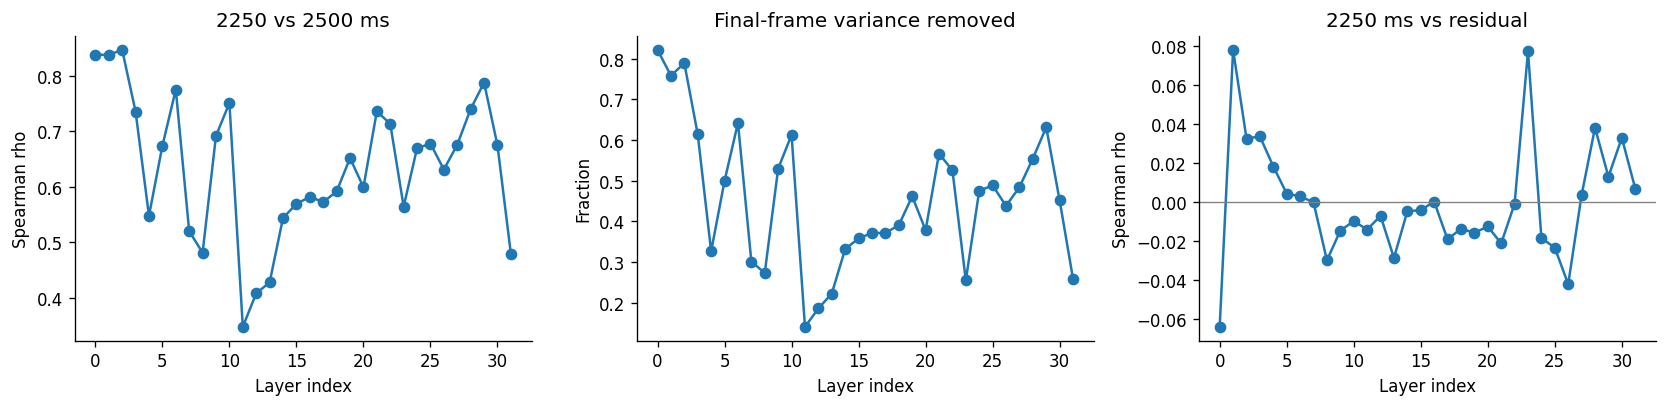

In [7]:
# Inspect how much geometry was removed and whether orthogonality holds.
variance_removed = np.asarray([
    summary["variance_removed"] for summary in regression_summaries
])
predictor_target_spearman = np.asarray([
    summary["predictor_target_spearman"]
    for summary in regression_summaries
])
predictor_residual_pearson = np.asarray([
    summary["predictor_residual_pearson"]
    for summary in regression_summaries
])
predictor_residual_spearman = np.asarray([
    summary["predictor_residual_spearman"]
    for summary in regression_summaries
])

print(
    "Variance removed across layers: "
    f"mean={variance_removed.mean():.3f}, "
    f"range=({variance_removed.min():.3f}, {variance_removed.max():.3f})"
)
print(
    "Maximum |Pearson r| between 2250-ms and residual RDMs: "
    f"{np.max(np.abs(predictor_residual_pearson)):.3e}"
)
print(
    "Residual Spearman correlation with 2250-ms RDMs: "
    f"mean={predictor_residual_spearman.mean():.3f}, "
    f"range=({predictor_residual_spearman.min():.3f}, "
    f"{predictor_residual_spearman.max():.3f})"
)

layer_index = np.arange(len(layer_names))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=cfg.figure_dpi)
axes[0].plot(layer_index, predictor_target_spearman, "o-")
axes[0].set(title="2250 vs 2500 ms", ylabel="Spearman rho")
axes[1].plot(layer_index, variance_removed, "o-")
axes[1].set(title="Final-frame variance removed", ylabel="Fraction")
axes[2].plot(layer_index, predictor_residual_spearman, "o-")
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set(title="2250 ms vs residual", ylabel="Spearman rho")
for axis in axes:
    axis.set_xlabel("Layer index")
    axis.spines[["top", "right"]].set_visible(False)
# end for axis
fig.tight_layout()

## Recompute the last-frame similarity timecourses and temporal scores

Timing is measured only inside `cfg.timing_window_ms`. Curves are smoothed for timing estimation, then values below the configured cutoff and all negative values receive zero weight. Latency is expressed relative to the 2500-ms final-frame onset.

In [8]:
"""
summarize_layer_timing
Compute smoothed curves plus centroid and peak latency for every model layer.

INPUT:
    - similarity: np.ndarray -> layers x dynamic-neural-time RSA values.
    - time_ms: np.ndarray -> dynamic neural time coordinate.
    - cfg: Cfg -> timing windows, smoothing, cutoffs, and frame onset.

OUTPUT:
    - smoothed_similarity: np.ndarray -> curves used for timing summaries.
    - centroid_latency_ms: np.ndarray -> positive-mass centroid minus frame onset.
    - peak_latency_ms: np.ndarray -> positive peak time minus frame onset.
"""
def summarize_layer_timing(similarity, time_ms, cfg):
    smoothed_similarity = gaussian_filter1d(
        similarity, sigma=cfg.smoothing_sigma_samples, axis=1,
    )
    centroid_window_mask = (
        (time_ms >= cfg.centroid_window_ms[0])
        & (time_ms < cfg.centroid_window_ms[1])
    )
    peak_window_mask = (
        (time_ms >= cfg.peak_window_ms[0])
        & (time_ms < cfg.peak_window_ms[1])
    )
    if not centroid_window_mask.any():
        raise ValueError("centroid_window_ms contains no neural samples.")
    # end if centroid window is empty
    if not peak_window_mask.any():
        raise ValueError("peak_window_ms contains no neural samples.")
    # end if peak window is empty
    centroid_window_time_ms = time_ms[centroid_window_mask]
    peak_window_time_ms = time_ms[peak_window_mask]
    centroid_latency_ms = []
    peak_latency_ms = []

    for layer_curve in smoothed_similarity:
        centroid_window_curve = layer_curve[centroid_window_mask]
        peak_window_curve = layer_curve[peak_window_mask]
        centroid_weights = np.where(
            np.isfinite(centroid_window_curve)
            & (centroid_window_curve > cfg.centroid_similarity_cutoff),
            centroid_window_curve, 0,
        )
        peak_values = np.where(
            np.isfinite(peak_window_curve)
            & (peak_window_curve > cfg.peak_similarity_cutoff),
            peak_window_curve, 0,
        )

        if centroid_weights.sum() > 0:
            centroid_time_ms = np.average(
                centroid_window_time_ms, weights=centroid_weights,
            )
            centroid_latency_ms.append(
                centroid_time_ms - cfg.last_frame_ms
            )
        else:
            centroid_latency_ms.append(np.nan)
        # end if centroid mass exists

        if peak_values.sum() > 0:
            peak_time_ms = peak_window_time_ms[np.argmax(peak_values)]
            peak_latency_ms.append(peak_time_ms - cfg.last_frame_ms)
        else:
            peak_latency_ms.append(np.nan)
        # end if positive peak exists
    # end for layer_curve

    return (
        smoothed_similarity, np.asarray(centroid_latency_ms),
        np.asarray(peak_latency_ms),
    )
# EOF

(
    raw_smoothed, raw_centroid_latency_ms, raw_peak_latency_ms,
) = summarize_layer_timing(raw_similarity, dynamic_time_ms, cfg)
(
    residual_smoothed, residual_centroid_latency_ms,
    residual_peak_latency_ms,
) = summarize_layer_timing(residual_similarity, dynamic_time_ms, cfg)

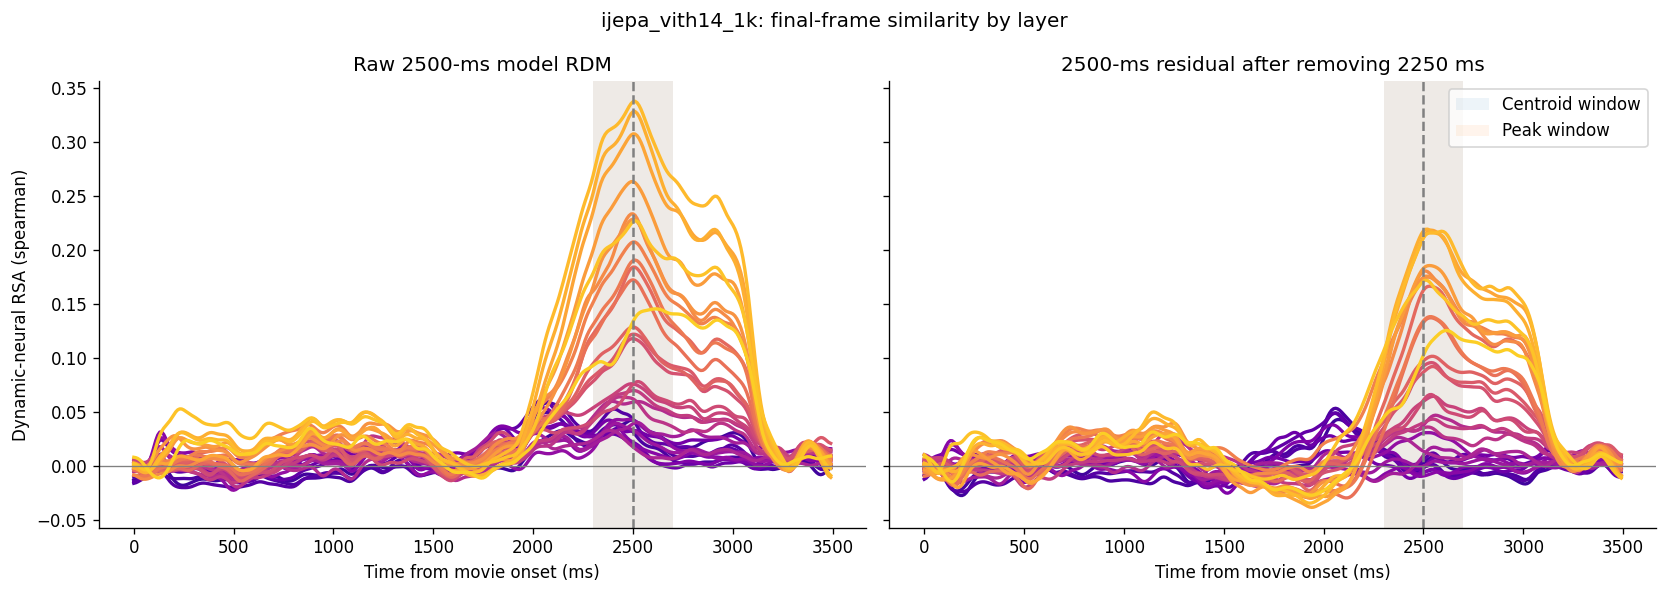

In [9]:
layer_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(layer_names)))
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for layer_index, layer_name in enumerate(layer_names):
    axes[0].plot(
        dynamic_time_ms, raw_smoothed[layer_index],
        color=layer_colors[layer_index], linewidth=cfg.linewidth,
    )
    axes[1].plot(
        dynamic_time_ms, residual_smoothed[layer_index],
        color=layer_colors[layer_index], linewidth=cfg.linewidth,
    )
# end for layer_index, layer_name

for axis in axes:
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.axvline(cfg.last_frame_ms, color="grey", linestyle="--")
    axis.axvspan(
        *cfg.centroid_window_ms, color="tab:blue", alpha=0.08,
        linewidth=0, label="Centroid window",
    )
    axis.axvspan(
        *cfg.peak_window_ms, color="tab:orange", alpha=0.08,
        linewidth=0, label="Peak window",
    )
    axis.set_xlabel("Time from movie onset (ms)")
    axis.spines[["top", "right"]].set_visible(False)
# end for axis
axes[0].set(
    title="Raw 2500-ms model RDM",
    ylabel=f"Dynamic-neural RSA ({cfg.rsa_metric})",
)
axes[1].set(title="2500-ms residual after removing 2250 ms")
axes[1].legend(loc="upper right")
fig.suptitle(f"{cfg.model_name}: final-frame similarity by layer")
fig.tight_layout()

Text(0.5, 0.98, 'ijepa_vith14_1k: final-frame representational timecourse')

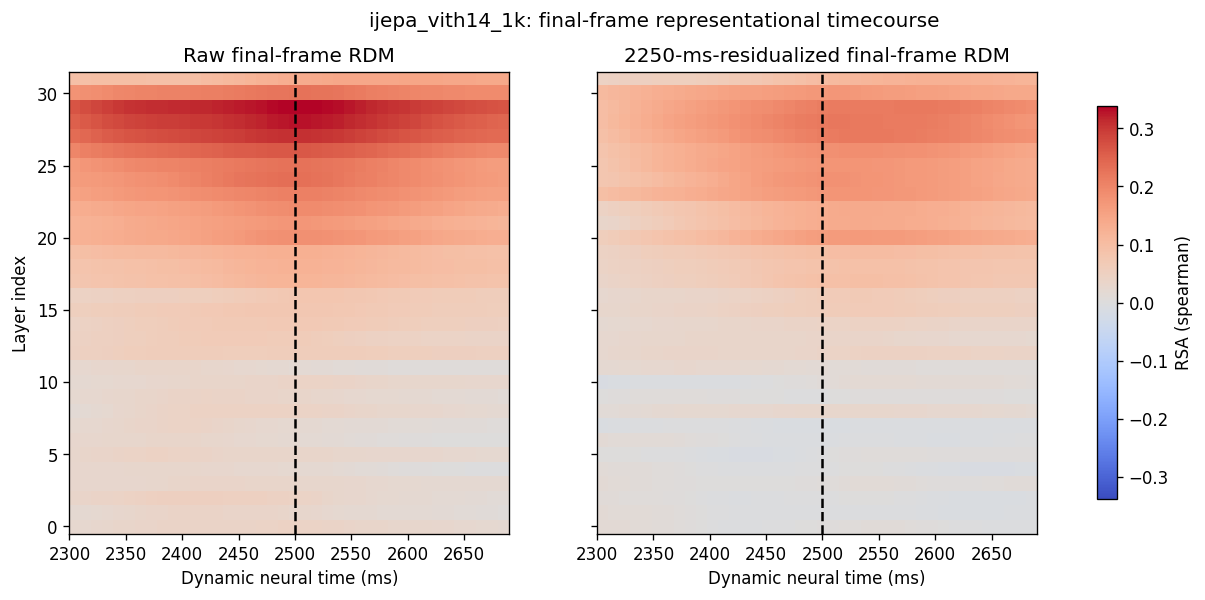

In [10]:
# A layer-by-time view makes any depth-dependent temporal progression visible.
timing_plot_window_ms = (
    min(cfg.centroid_window_ms[0], cfg.peak_window_ms[0]),
    max(cfg.centroid_window_ms[1], cfg.peak_window_ms[1]),
)
plot_mask = (
    (dynamic_time_ms >= timing_plot_window_ms[0])
    & (dynamic_time_ms < timing_plot_window_ms[1])
)
color_limit = np.nanmax(np.abs(np.concatenate([
    raw_smoothed[:, plot_mask].ravel(),
    residual_smoothed[:, plot_mask].ravel(),
])))
fig, axes = plt.subplots(
    1, 2, figsize=(13, 5), sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for axis, values, title in zip(
        axes,
        (raw_smoothed, residual_smoothed),
        ("Raw final-frame RDM", "2250-ms-residualized final-frame RDM"),
        ):
    image = axis.imshow(
        values[:, plot_mask], aspect="auto", origin="lower",
        cmap="coolwarm", vmin=-color_limit, vmax=color_limit,
        extent=(
            dynamic_time_ms[plot_mask][0], dynamic_time_ms[plot_mask][-1],
            -0.5, len(layer_names) - 0.5,
        ),
    )
    axis.axvline(cfg.last_frame_ms, color="black", linestyle="--")
    axis.set(title=title, xlabel="Dynamic neural time (ms)")
# end for axis, values, title
axes[0].set_ylabel("Layer index")
fig.colorbar(
    image, ax=axes, label=f"RSA ({cfg.rsa_metric})", shrink=0.85,
)
fig.suptitle(f"{cfg.model_name}: final-frame representational timecourse")

In [11]:
timing_values = {
    "raw": {
        "centroid": raw_centroid_latency_ms,
        "peak": raw_peak_latency_ms,
    },
    "residual": {
        "centroid": residual_centroid_latency_ms,
        "peak": residual_peak_latency_ms,
    },
}
temporal_scores = {}
for condition_name, condition_values in timing_values.items():
    temporal_scores[condition_name] = {}
    for timing_name, latency_ms in condition_values.items():
        valid_layers = np.isfinite(latency_ms)
        if valid_layers.sum() < 2:
            score = np.nan
            pvalue = np.nan
        else:
            score_result = spearmanr(
                layer_depths[valid_layers], latency_ms[valid_layers],
            )
            score = score_result.statistic
            pvalue = score_result.pvalue
        # end if fewer than two valid layers
        temporal_scores[condition_name][timing_name] = {
            "rho": score, "pvalue": pvalue,
            "n_layers": int(valid_layers.sum()),
        }
    # end for timing_name, latency_ms
# end for condition_name, condition_values

for condition_name in ("raw", "residual"):
    for timing_name in ("centroid", "peak"):
        result = temporal_scores[condition_name][timing_name]
        print(
            f"{condition_name:8s} {timing_name:8s}: "
            f"rho={result['rho']:.3f}, p={result['pvalue']:.3g}, "
            f"n={result['n_layers']}"
        )
    # end for timing_name
# end for condition_name

raw      centroid: rho=0.618, p=0.000162, n=32
raw      peak    : rho=0.751, p=7.48e-07, n=32
residual centroid: rho=0.498, p=0.00699, n=28
residual peak    : rho=0.421, p=0.0256, n=28


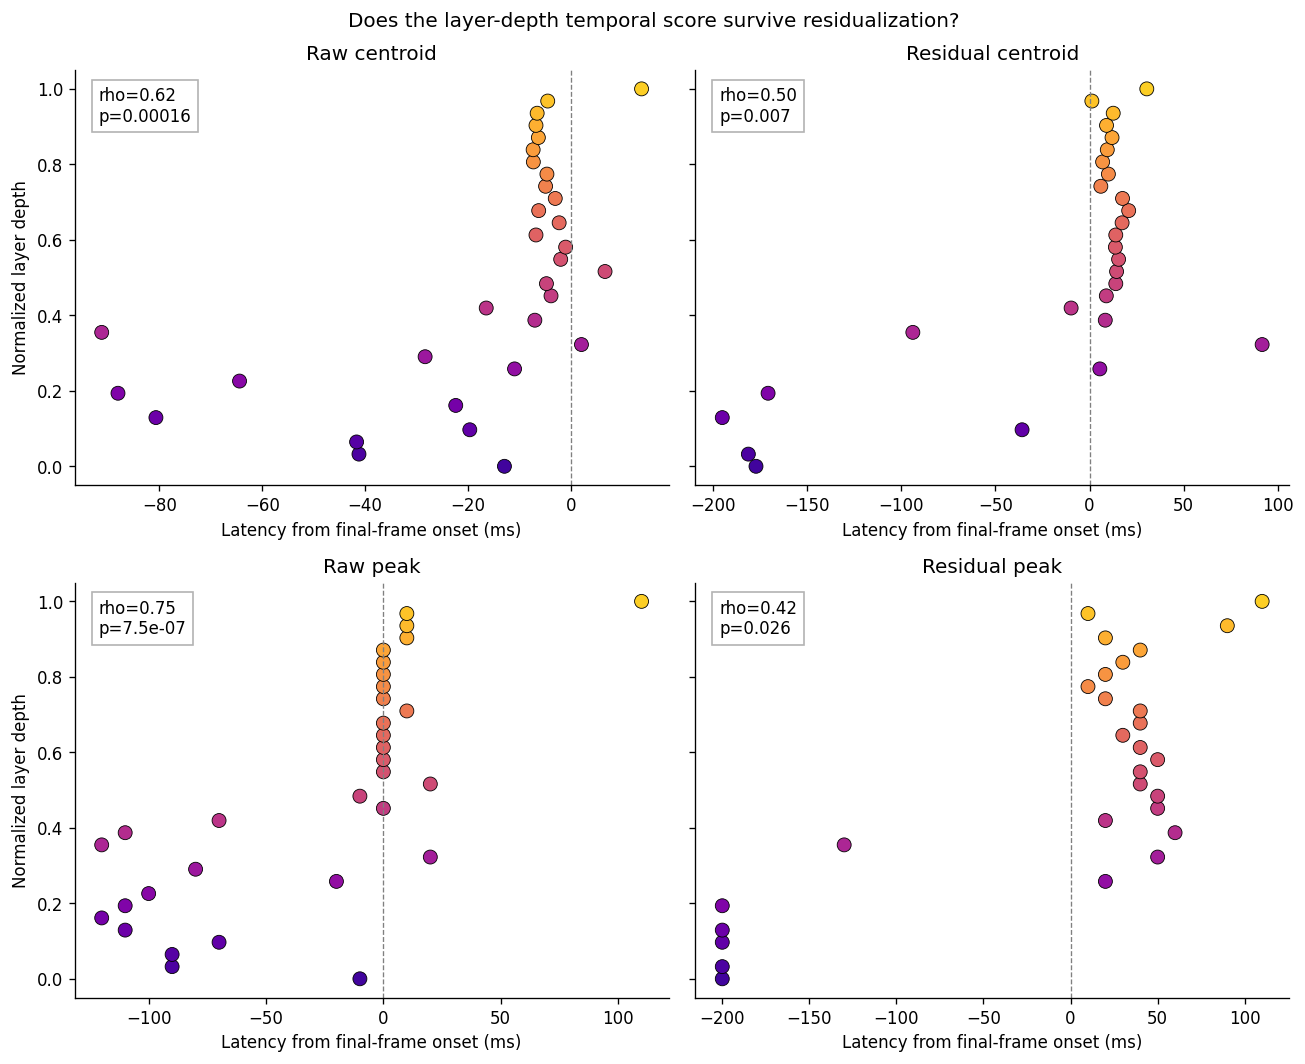

In [12]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 9), sharey=True, dpi=cfg.figure_dpi,
)
for row_index, timing_name in enumerate(("centroid", "peak")):
    for column_index, condition_name in enumerate(("raw", "residual")):
        axis = axes[row_index, column_index]
        latency_ms = timing_values[condition_name][timing_name]
        valid_layers = np.isfinite(latency_ms)
        score = temporal_scores[condition_name][timing_name]
        axis.scatter(
            latency_ms[valid_layers], layer_depths[valid_layers],
            c=layer_colors[valid_layers], s=70, edgecolors="black",
            linewidths=0.5,
        )
        axis.axvline(0, color="grey", linestyle="--", linewidth=0.8)
        axis.text(
            0.04, 0.96,
            f"rho={score['rho']:.2f}\np={score['pvalue']:.2g}",
            transform=axis.transAxes, ha="left", va="top",
            bbox={"facecolor": "white", "edgecolor": "0.7"},
        )
        axis.set(
            title=f"{condition_name.capitalize()} {timing_name}",
            xlabel="Latency from final-frame onset (ms)",
        )
        axis.spines[["top", "right"]].set_visible(False)
    # end for column_index, condition_name
    axes[row_index, 0].set_ylabel("Normalized layer depth")
# end for row_index, timing_name
fig.suptitle("Does the layer-depth temporal score survive residualization?")
fig.tight_layout()

Temporal-score comparison
Centroid: raw rho=0.618 (p=0.000162); residual rho=0.498 (p=0.00699)
Peak: raw rho=0.751 (p=7.48e-07); residual rho=0.421 (p=0.0256)


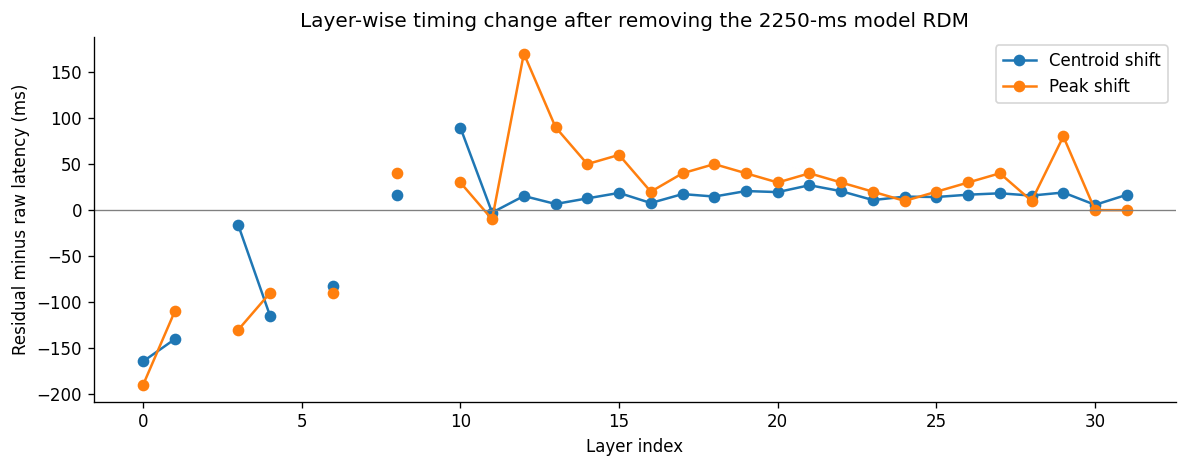

In [13]:
# Report the change in each timing measure without hiding layer-level effects.
centroid_shift_ms = (
    residual_centroid_latency_ms - raw_centroid_latency_ms
)
peak_shift_ms = residual_peak_latency_ms - raw_peak_latency_ms
layer_indices = np.arange(len(layer_names))

fig, axis = plt.subplots(figsize=(10, 4), dpi=cfg.figure_dpi)
axis.plot(layer_indices, centroid_shift_ms, "o-", label="Centroid shift")
axis.plot(layer_indices, peak_shift_ms, "o-", label="Peak shift")
axis.axhline(0, color="grey", linewidth=0.8)
axis.set(
    xlabel="Layer index", ylabel="Residual minus raw latency (ms)",
    title="Layer-wise timing change after removing the 2250-ms model RDM",
)
axis.legend()
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

raw_centroid_score = temporal_scores["raw"]["centroid"]
residual_centroid_score = temporal_scores["residual"]["centroid"]
raw_peak_score = temporal_scores["raw"]["peak"]
residual_peak_score = temporal_scores["residual"]["peak"]

print("Temporal-score comparison")
print(
    f"Centroid: raw rho={raw_centroid_score['rho']:.3f} "
    f"(p={raw_centroid_score['pvalue']:.3g}); residual rho="
    f"{residual_centroid_score['rho']:.3f} "
    f"(p={residual_centroid_score['pvalue']:.3g})"
)
print(
    f"Peak: raw rho={raw_peak_score['rho']:.3f} "
    f"(p={raw_peak_score['pvalue']:.3g}); residual rho="
    f"{residual_peak_score['rho']:.3f} "
    f"(p={residual_peak_score['pvalue']:.3g})"
)

## Interpretation

The key comparison is the final printed block and the four depth-versus-latency panels. A temporal score **holds** after control when the residual centroid or peak latency still increases monotonically with layer depth (positive $\rho$) and the corresponding evidence remains convincing. If the raw score is positive but the residual score approaches zero or reverses, the original effect was largely carried by representational geometry already present at 2250 ms.

The residualization diagnostic should show Pearson correlations numerically near zero. A remaining Spearman correlation is possible because the OLS regression removes linear variance in raw RDM-distance space, whereas the final RSA is rank-based when `cfg.rsa_metric="spearman"`. Set `rsa_metric="correlation"` if the desired inferential test should stay entirely in the same linear space.

## Residual temporal scores across movie frames

This section reproduces the presentation's layer depth–latency grid for successive target-frame slices. At every eligible target time, each layer's target RDM is first regressed on the RDM from exactly `cfg.frame_residual_delay_ms` earlier. Frames without that earlier predictor are omitted. The first figure shows the residual RSA timecourses that supply the latency values in the scatterplots immediately below it.

In [14]:
# Start from the same evenly spaced target-frame grid as OC_presentation.
candidate_frame_indices = np.rint(np.linspace(
    0, model_time_ms.size - 1, cfg.frame_latency_n_scatterplots,
)).astype(int)
if np.unique(candidate_frame_indices).size != len(candidate_frame_indices):
    raise ValueError("Even frame sampling produced duplicate indices.")
# end if sampled frame indices are not unique

# Omit targets for which the requested causal predictor does not exist.
earliest_target_ms = model_time_ms[0] + cfg.frame_residual_delay_ms
valid_target_mask = (
    model_time_ms[candidate_frame_indices] >= earliest_target_ms
)
selected_frame_indices = candidate_frame_indices[valid_target_mask]
skipped_frame_indices = candidate_frame_indices[~valid_target_mask]
selected_frame_times_ms = model_time_ms[selected_frame_indices]

# Store one full neural RSA timecourse for every target-frame/layer pair.
frame_residual_similarity = np.full(
    (len(selected_frame_indices), len(layer_names), len(dynamic_time_ms)),
    np.nan,
)
frame_regression_summaries = np.empty(
    (len(selected_frame_indices), len(layer_names)), dtype=object,
)

for layer_index, feature_path in enumerate(feature_paths):
    model_features, current_layer_name, layer_source_fs = (
        load_aligned_video_features(
            feature_path, model_stimulus_names, frame_index=None,
        )
    )
    if current_layer_name != layer_names[layer_index]:
        raise ValueError("Layer order changed while reloading features.")
    # end if layer order changed
    model_ts = TimeSeries(model_features, fs=layer_source_fs)
    model_ts.resample(cfg.analysis_fs)
    current_model_time_ms = (
        np.arange(len(model_ts)) * 1000 / model_ts.get_fs()
    )
    if not np.array_equal(current_model_time_ms, model_time_ms):
        raise ValueError("Model layers have inconsistent time grids.")
    # end if model time grids differ
    model_array = model_ts.get_array()

    for plot_index, target_frame_index in enumerate(
            selected_frame_indices):
        target_time_ms = model_time_ms[target_frame_index]
        predictor_time_ms = (
            target_time_ms - cfg.frame_residual_delay_ms
        )
        predictor_frame_index = int(np.argmin(
            np.abs(model_time_ms - predictor_time_ms)
        ))
        if not np.isclose(
                model_time_ms[predictor_frame_index], predictor_time_ms):
            raise ValueError(
                f"Model grid misses the {predictor_time_ms:g}-ms "
                "predictor frame."
            )
        # end if predictor time is absent

        predictor_rdm = create_RDM(
            np.ascontiguousarray(
                model_array[:, predictor_frame_index, :]
            ),
            metric=cfg.model_rdm_metric,
        )
        target_rdm = create_RDM(
            np.ascontiguousarray(
                model_array[:, target_frame_index, :]
            ),
            metric=cfg.model_rdm_metric,
        )
        residual_rdm, regression_summary = regress_out_rdm(
            target_rdm, predictor_rdm,
            fit_intercept=cfg.regression_fit_intercept,
        )
        frame_residual_similarity[plot_index, layer_index] = (
            cross_temporal_similarity(
                dynamic_neural_rdms, residual_rdm[np.newaxis, :],
                metric=cfg.rsa_metric,
            )[:, 0]
        )
        frame_regression_summaries[plot_index, layer_index] = (
            regression_summary
        )
    # end for plot_index, target_frame_index
# end for layer_index, feature_path

# Smooth only along neural time, never across layers or target frames.
frame_residual_smoothed = gaussian_filter1d(
    frame_residual_similarity, sigma=cfg.smoothing_sigma_samples, axis=2,
)
frame_latency_values_ms = np.full(
    (len(selected_frame_indices), len(layer_names)), np.nan,
)
frame_latency_correlations = np.full(
    (len(selected_frame_indices), 2), np.nan,
)

for plot_index, target_time_ms in enumerate(selected_frame_times_ms):
    relative_neural_time_ms = dynamic_time_ms - target_time_ms
    latency_window = (
        (relative_neural_time_ms >= cfg.frame_latency_window_ms[0])
        & (relative_neural_time_ms < cfg.frame_latency_window_ms[1])
    )
    if not latency_window.any():
        raise ValueError(
            f"Target {target_time_ms:g} ms has an empty latency window."
        )
    # end if latency window is empty
    window_time_ms = relative_neural_time_ms[latency_window]

    for layer_index in range(len(layer_names)):
        window_similarity = frame_residual_smoothed[
            plot_index, layer_index, latency_window
        ]
        if cfg.frame_latency_measure == "centroid":
            # Positive residual RSA above cutoff supplies centroid weight.
            latency_weights = np.where(
                np.isfinite(window_similarity)
                & (window_similarity > cfg.centroid_similarity_cutoff),
                window_similarity, 0,
            )
            if latency_weights.sum() > 0:
                frame_latency_values_ms[plot_index, layer_index] = (
                    np.average(window_time_ms, weights=latency_weights)
                )
            # end if layer has positive centroid weight
        else:
            # Peak latency uses the strongest finite RSA above cutoff.
            peak_similarity = np.where(
                np.isfinite(window_similarity)
                & (window_similarity > cfg.peak_similarity_cutoff),
                window_similarity, 0,
            )
            if peak_similarity.max(initial=0) > 0:
                frame_latency_values_ms[plot_index, layer_index] = (
                    window_time_ms[np.argmax(peak_similarity)]
                )
            # end if layer has a valid peak
        # end if frame latency measure is centroid
    # end for layer_index

    valid_layers = np.isfinite(frame_latency_values_ms[plot_index])
    if valid_layers.sum() >= 2:
        score_result = spearmanr(
            frame_latency_values_ms[plot_index, valid_layers],
            layer_depths[valid_layers],
        )
        frame_latency_correlations[plot_index] = (
            score_result.statistic, score_result.pvalue,
        )
    # end if at least two layer latencies are valid
# end for plot_index, target_time_ms

print(
    "Skipped target frames without a -"
    f"{cfg.frame_residual_delay_ms:g} ms predictor: "
    f"{model_time_ms[skipped_frame_indices].astype(int).tolist()} ms"
)
print(
    "Analyzed residual target frames: "
    f"{selected_frame_times_ms.astype(int).tolist()} ms"
)
# EOF

Skipped target frames without a -250 ms predictor: [0, 160] ms
Analyzed residual target frames: [310, 470, 630, 790, 940, 1100, 1260, 1420, 1570, 1730, 1890, 2050, 2200, 2360, 2520, 2680, 2830, 2990] ms


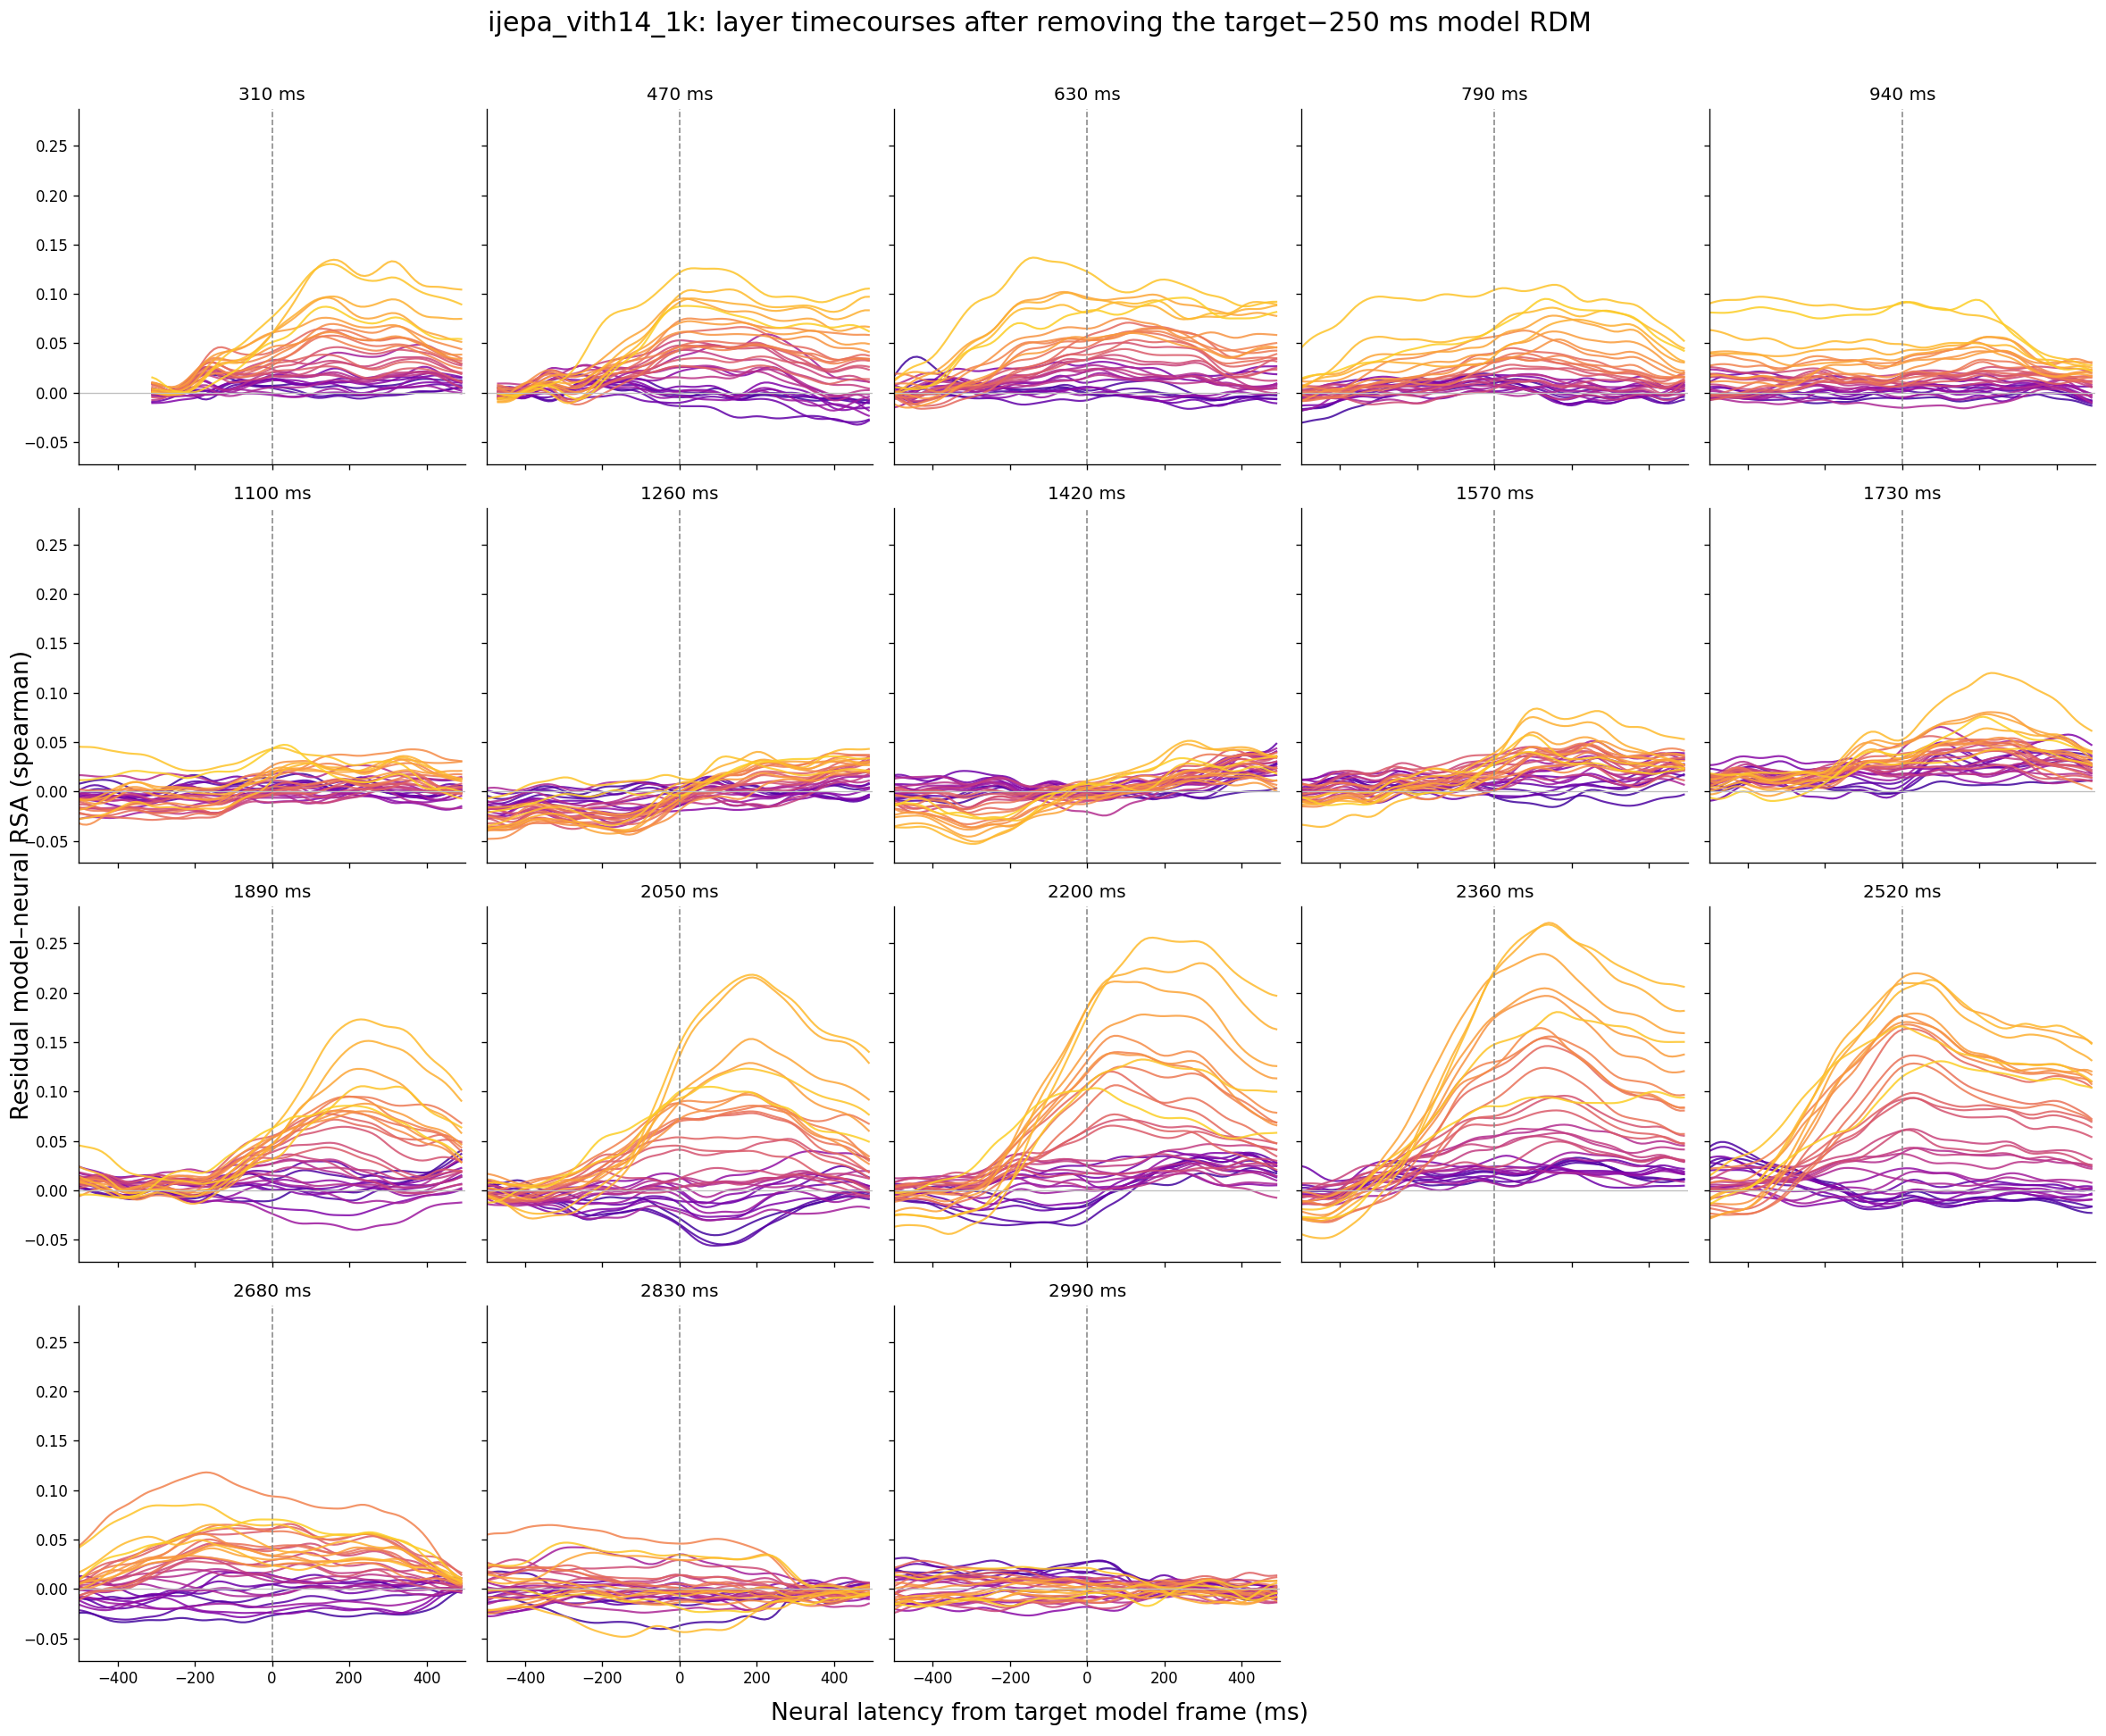

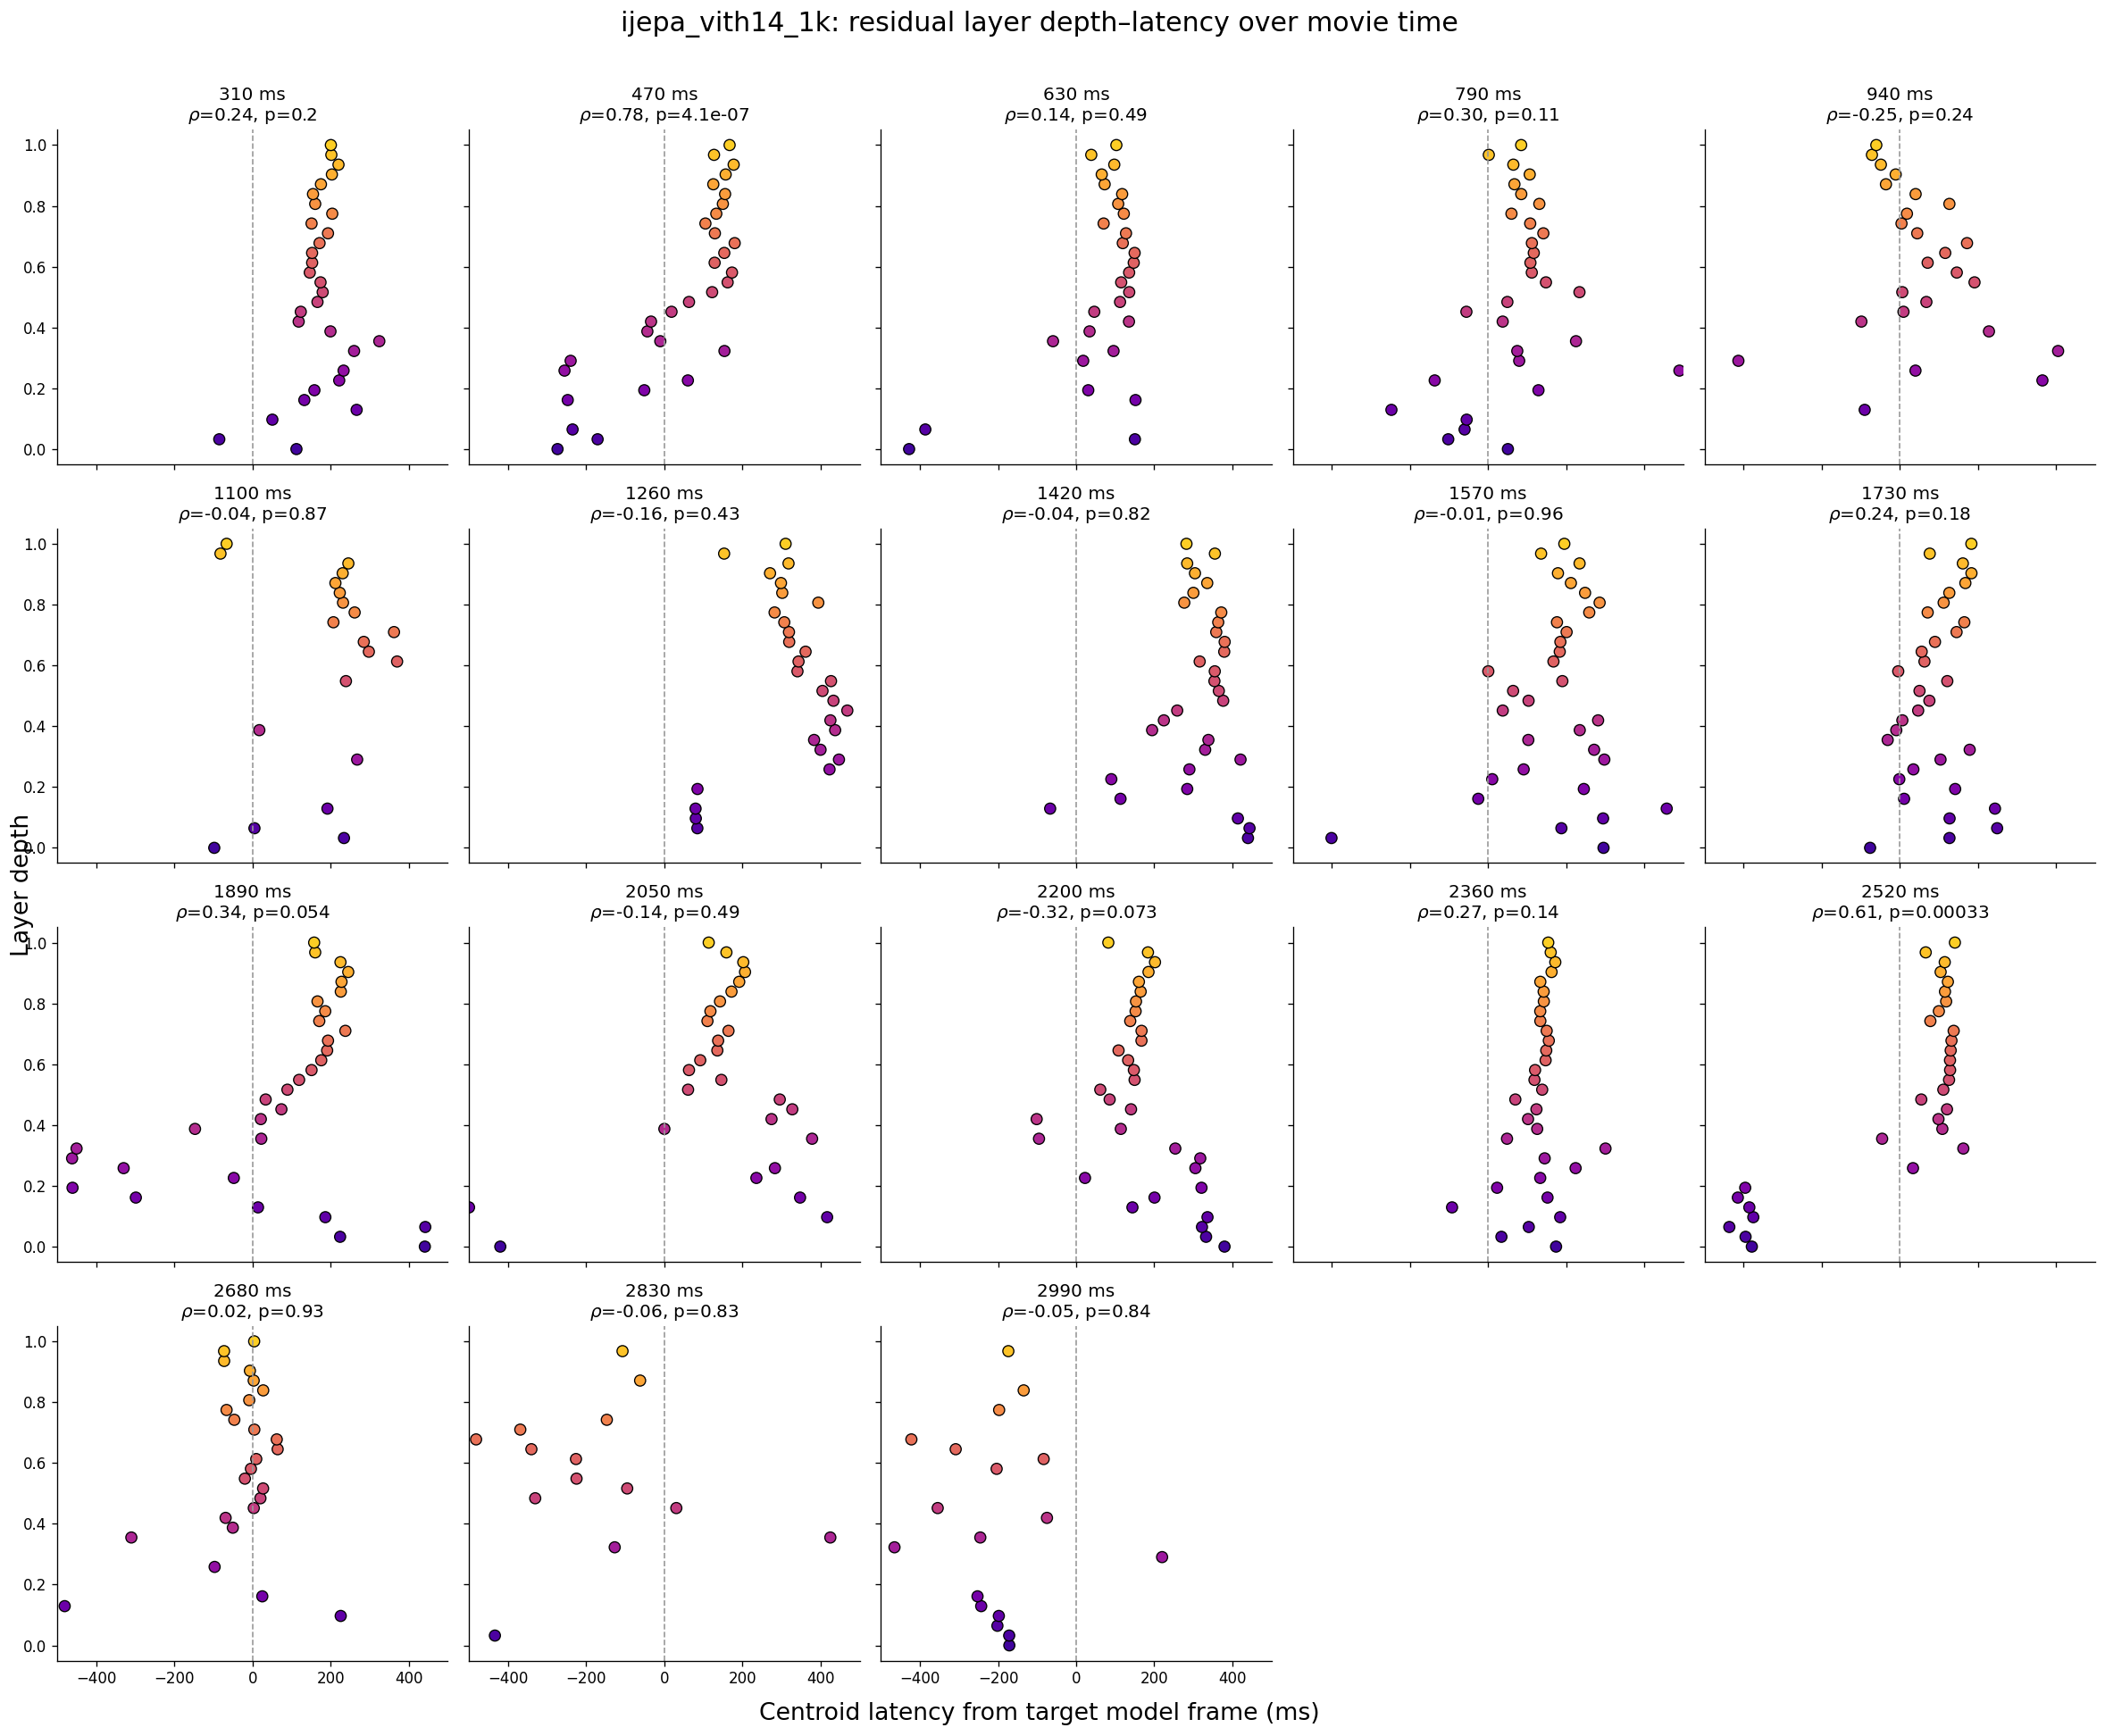

In [15]:
# Show the all-layer residual timecourses used by each scatterplot.
n_rows, n_columns = cfg.frame_latency_grid_shape
figure, axes = plt.subplots(
    n_rows, n_columns, figsize=cfg.frame_latency_grid_figsize,
    sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for plot_index, axis in enumerate(axes.flat):
    if plot_index >= len(selected_frame_times_ms):
        axis.set_visible(False)
        continue
    # end if no target frame belongs in this panel
    target_time_ms = selected_frame_times_ms[plot_index]
    relative_neural_time_ms = dynamic_time_ms - target_time_ms
    plot_window = (
        (relative_neural_time_ms >= cfg.frame_latency_window_ms[0])
        & (relative_neural_time_ms < cfg.frame_latency_window_ms[1])
    )
    for layer_index in range(len(layer_names)):
        axis.plot(
            relative_neural_time_ms[plot_window],
            frame_residual_smoothed[
                plot_index, layer_index, plot_window
            ],
            color=layer_colors[layer_index], linewidth=1.3, alpha=0.85,
        )
    # end for layer_index
    axis.axhline(0, color="0.75", linewidth=0.8)
    axis.axvline(0, color="0.55", linewidth=1, linestyle="--")
    axis.set_title(f"{target_time_ms:.0f} ms", fontsize=12)
    axis.set_xlim(cfg.frame_latency_window_ms)
    axis.tick_params(axis="both", labelsize=10)
    axis.spines[["top", "right"]].set_visible(False)
# end for plot_index, axis
figure.supxlabel(
    "Neural latency from target model frame (ms)", fontsize=16,
)
figure.supylabel(
    f"Residual model–neural RSA ({cfg.rsa_metric})", fontsize=16,
)
figure.suptitle(
    f"{cfg.model_name}: layer timecourses after removing the "
    f"target−{cfg.frame_residual_delay_ms:g} ms model RDM",
    fontsize=18, y=1.01,
)
figure.tight_layout()
plt.show()

# Plot the corresponding layer depth–latency temporal scores below.
figure, axes = plt.subplots(
    n_rows, n_columns, figsize=cfg.frame_latency_grid_figsize,
    sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for plot_index, axis in enumerate(axes.flat):
    if plot_index >= len(selected_frame_times_ms):
        axis.set_visible(False)
        continue
    # end if no target frame belongs in this panel
    valid_layers = np.isfinite(frame_latency_values_ms[plot_index])
    axis.scatter(
        frame_latency_values_ms[plot_index, valid_layers],
        layer_depths[valid_layers],
        c=layer_colors[valid_layers], s=cfg.frame_latency_scatter_size,
        edgecolors=cfg.frame_latency_edge_color,
        linewidths=cfg.frame_latency_edge_width,
    )
    rho_value, p_value = frame_latency_correlations[plot_index]
    axis.set_title(
        f"{selected_frame_times_ms[plot_index]:.0f} ms\n"
        fr"$\rho$={rho_value:.2f}, p={p_value:.2g}",
        fontsize=12,
    )
    axis.axvline(0, color="0.6", linewidth=1, linestyle="--")
    axis.set(
        xlim=cfg.frame_latency_window_ms, ylim=(-0.05, 1.05),
        yticks=np.linspace(0, 1, 6),
    )
    axis.tick_params(axis="both", labelsize=10)
    axis.spines[["top", "right"]].set_visible(False)
# end for plot_index, axis
figure.supxlabel(
    f"{cfg.frame_latency_measure.capitalize()} latency from target "
    "model frame (ms)",
    fontsize=16,
)
figure.supylabel("Layer depth", fontsize=16)
figure.suptitle(
    f"{cfg.model_name}: residual layer depth–latency over movie time",
    fontsize=18, y=1.01,
)
figure.tight_layout()
plt.show()
# EOF

## Per-layer peak model fit before and after residualization

For each layer, the **peak model fit** is the maximum smoothed model–neural RSA inside a peak window. Three comparisons:

- **Movie, last frame**: the 2500-ms model RDM, raw and after removing the 2250-ms RDM, against the dynamic session; peak inside `cfg.peak_window_ms`.
- **Movie, first slice**: the first target frame of the frame grid above, raw and after removing the RDM `cfg.frame_residual_delay_ms` earlier; peak inside the last-frame window shifted to that target frame.
- **Image, static dRSA**: the static model RDM (final-frame features) against the image-session neural RDM timecourse; raw only, since a static stimulus has no earlier frame to regress out. Peak inside `cfg.image_peak_window_ms` from image onset.

In [16]:
# The first grid target is the earliest frame with a causal predictor.
first_slice_ms = selected_frame_times_ms[0]
# Movie window keeps the same offsets from the target as at the last frame.
first_slice_peak_window_ms = (
    float(first_slice_ms + cfg.peak_window_ms[0] - cfg.last_frame_ms),
    float(first_slice_ms + cfg.peak_window_ms[1] - cfg.last_frame_ms),
)
(
    first_slice_layer_names, first_slice_raw_similarity,
    first_slice_residual_similarity, _,
) = last_frame_residual_similarity(
    dynamic_neural_rdms, dynamic_feature_names, model_features_dir,
    cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
    cfg.analysis_fs, first_slice_ms - cfg.frame_residual_delay_ms,
    first_slice_ms, cfg.model_rdm_metric, cfg.rsa_metric,
    cfg.regression_fit_intercept,
)
if first_slice_layer_names != layer_names:
    raise ValueError("First-slice layer order differs.")
# end if layer order differs

# Image-session neural RDMs (time x stimulus pairs); the image appears at 0 ms.
image_state = prepare_static_neural_rdms(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    source_fs=cfg.source_neural_fs,
    new_fs=cfg.analysis_fs,
    crop_ms=cfg.image_crop_ms,
    rdm_metric=cfg.neural_rdm_metric,
)
if not np.array_equal(
        image_state["channel_numbers"], selected_channel_numbers):
    raise ValueError(
        "Image and movie analyses use different channels; set top_k=None."
    )
# end if channel pools differ

# Static dRSA: one static model RDM per layer against every neural RDM.
image_drsa = dRSA(
    signal_RDM_metric=cfg.neural_rdm_metric,
    model_RDM_metric=cfg.model_rdm_metric,
    RSA_metric=cfg.rsa_metric,
)
image_drsa.set_RDM_timeseries(
    TimeSeries(list(image_state["neural_rdms"]), cfg.analysis_fs), "signal",
)
image_model_stimulus_names = match_feature_stimulus_names(
    feature_paths[0], image_state["stimulus_names"],
)
image_static_similarity = []
for layer_index, feature_path in enumerate(feature_paths):
    # features x stimuli at the final frame, i.e. the static image.
    image_features, current_layer_name, _ = load_aligned_video_features(
        feature_path, image_model_stimulus_names, frame_index=-1,
    )
    if current_layer_name != layer_names[layer_index]:
        raise ValueError("Layer order changed while loading image features.")
    # end if layer order changed
    image_drsa.set_RDM(
        create_RDM(image_features, metric=cfg.model_rdm_metric), "model",
    )
    image_static_similarity.append(
        image_drsa.compute_static_dRSA().get_array().copy()
    )
# end for layer_index, feature_path
image_static_similarity = np.stack(image_static_similarity)

# panel title -> ({condition: layers x neural time}, neural time, peak window).
peak_fit_inputs = {
    "Movie, last frame": (
        {"raw": raw_similarity, "residual": residual_similarity},
        dynamic_time_ms, cfg.peak_window_ms,
    ),
    f"Movie, first slice ({first_slice_ms:.0f} ms)": (
        {
            "raw": first_slice_raw_similarity,
            "residual": first_slice_residual_similarity,
        },
        dynamic_time_ms, first_slice_peak_window_ms,
    ),
    "Image, static dRSA": (
        {"raw": image_static_similarity}, image_state["time_ms"],
        cfg.image_peak_window_ms,
    ),
}

# Peak fit = max of the smoothed RSA curve inside each panel's window.
peak_fit = {}
for panel_title, (
        condition_similarity, neural_time_ms, peak_window_ms,
        ) in peak_fit_inputs.items():
    window_mask = (
        (neural_time_ms >= peak_window_ms[0])
        & (neural_time_ms < peak_window_ms[1])
    )
    if not window_mask.any():
        raise ValueError(f"{panel_title}: peak window has no samples.")
    # end if peak window is empty
    peak_fit[panel_title] = {}
    for condition_name, similarity in condition_similarity.items():
        smoothed = gaussian_filter1d(
            similarity, sigma=cfg.smoothing_sigma_samples, axis=1,
        )
        peak_fit[panel_title][condition_name] = smoothed[:, window_mask].max(
            axis=1,
        )
    # end for condition_name, similarity
    mean_peaks = ", ".join(
        f"{condition_name}={values.mean():.3f}"
        for condition_name, values in peak_fit[panel_title].items()
    )
    print(f"{panel_title:28s} window={peak_window_ms} ms  mean peak {mean_peaks}")
# end for panel_title

Movie, last frame            window=(2300, 2700) ms  mean peak raw=0.126, residual=0.088
Movie, first slice (310 ms)  window=(110.0, 510.0) ms  mean peak raw=0.062, residual=0.045
Image, static dRSA           window=(0, 400) ms  mean peak raw=0.131


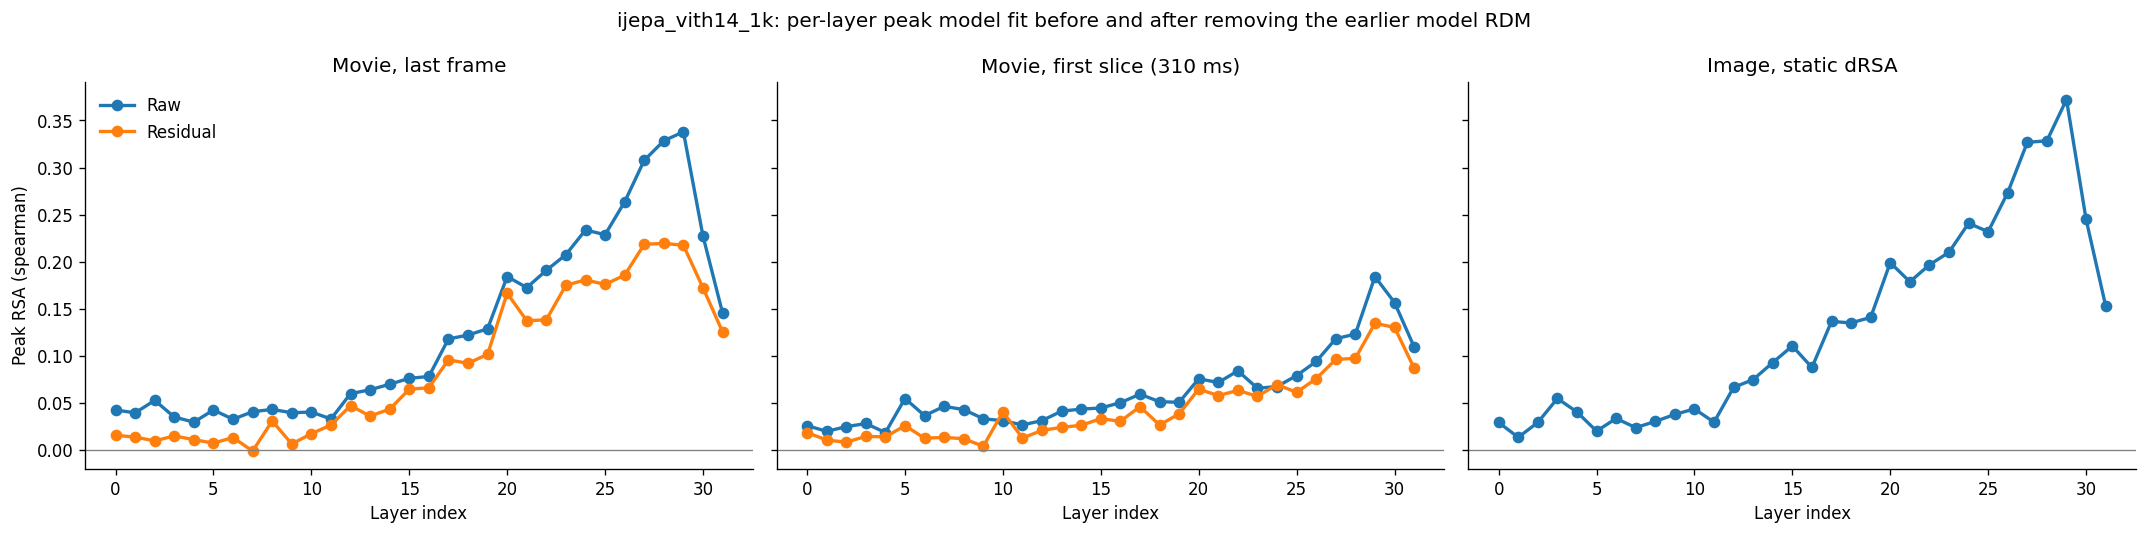

In [17]:
# One panel per comparison; the image panel has no residual line.
layer_index = np.arange(len(layer_names))
condition_colors = {"raw": "tab:blue", "residual": "tab:orange"}
figure, axes = plt.subplots(
    1, 3, figsize=(18, 4.5), sharex=True, sharey=True, dpi=cfg.figure_dpi,
)
for axis, panel_title in zip(axes, peak_fit):
    for condition_name, values in peak_fit[panel_title].items():
        axis.plot(
            layer_index, values, "o-", color=condition_colors[condition_name],
            linewidth=cfg.linewidth, label=condition_name.capitalize(),
        )
    # end for condition_name, values
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.set(title=panel_title, xlabel="Layer index")
    axis.spines[["top", "right"]].set_visible(False)
# end for axis, panel_title
axes[0].set_ylabel(f"Peak RSA ({cfg.rsa_metric})")
axes[0].legend(frameon=False)
figure.suptitle(
    f"{cfg.model_name}: per-layer peak model fit before and after "
    "removing the earlier model RDM"
)
figure.tight_layout()
plt.show()